In [6]:
"""
=============================================================================
PRUEBA TÉCNICA - DATA SCIENTIST JR. | SOLVENTA
=============================================================================
Script 02 — Análisis Exploratorio de Datos (EDA) + Information Value (IV)
Autor   : Javier Yesid Ladino Santamaria
Fecha   : 2026-04
 
Contenido:
    1. Limpieza de datos
    2. Análisis de Tendencia
    3. Distribución del target (Mora60)
    4. EDA variables numéricas
       4.3 Distribución por variable vs target
       4.2 Boxplots por target (detección de outliers)
       4.3 Matriz de correlación
    5. EDA variables categóricas
       5.1 Tasa de default por categoría
    6. Cálculo de Information Value (IV) — todas las variables
    7. Ranking final de variables por IV
    8. Curvas WoE — top 6 variables
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")
 
# Importar función de limpieza del script anterior
import importlib.util
spec = importlib.util.spec_from_file_location("limpieza", "01_limpieza_datos.py")
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
limpiar_datos = mod.limpiar_datos

# =============================================================================
# CONFIGURACIÓN VISUAL
# =============================================================================
 
COLOR_BUENO = "#4C72B0"
COLOR_MALO  = "#C44E52"
PALETTE     = [COLOR_BUENO, COLOR_MALO]
 
plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#F7F7F7",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 11,
    "axes.labelsize"    : 10,
})
 
# =============================================================================
# CARGA Y LIMPIEZA
# =============================================================================
 
df_raw            = pd.read_excel("ProductoNuevo.xlsx")
df_clean, _       = limpiar_datos(df_raw, verbose=False)
 
TARGET       = "Mora60"
TASA_GLOBAL  = df_clean[TARGET].mean()
 
print(f"Dataset limpio : {df_clean.shape[0]:,} registros | {df_clean.shape[1]} columnas")
print(f"Tasa de default: {TASA_GLOBAL:.2%}  (Malos: {df_clean[TARGET].sum()} | Buenos: {(df_clean[TARGET]==0).sum()})\n")
 
# Variables a analizar
EXCLUIR   = ["ID", "FFECHA", "Mora30", "Mora60"]
NUM_COLS  = [c for c in df_clean.select_dtypes(include=np.number).columns if c not in EXCLUIR]
CAT_COLS  = ["OCUPACION", "TIPCONTRATO", "Estado_Civil", "Genero", "Nivel_Academico", "Tipo_Vivienda"]
 
# Variables numéricas para gráficos (excluye binarias y flags)
NUM_PLOT  = [c for c in NUM_COLS
             if c not in ["flag_arriendo_imputado", "flag_actividad_inconsistente",
                          "ExperienciaSectorFinanciero"]]


Dataset limpio : 4,315 registros | 24 columnas
Tasa de default: 11.68%  (Malos: 504 | Buenos: 3811)



# **1. Limpieza y calidad de datos — Hallazgos y decisiones**

Durante la revisión de calidad se identificaron errores de captura, inconsistencias lógicas y valores atípicos extremos en cinco variables. A continuación se documenta cada hallazgo y la decisión de tratamiento adoptada.

**Criterio general: imputación y capping, no eliminación**

Ningún registro fue eliminado del dataset. Con 504 eventos de incumplimiento (Mora60), cada observación es valiosa para el entrenamiento del modelo. Los errores identificados son puntuales en variables específicas — el resto de la información del cliente sigue siendo válida y útil. La eliminación de registros solo estaría justificada ante casos irrecuperables: duplicados exactos, más del 50% de variables faltantes, o contradicciones lógicas en la variable objetivo.

**Correcciones aplicadas**

- ```GastoArriendo = 1``` **(7 registros)** Valor económicamente imposible para un gasto de arriendo. Todos los registros corresponden a vivienda tipo FAMILIAR, donde el arriendo esperado es cero. Se interpreta como un placeholder de dato faltante ingresado en el sistema de originación. Corrección: reemplazar por 0.

- ```GastoArriendo > 0``` en vivienda PROPIA (1 registro)
Un cliente con vivienda propia no debería registrar gasto de arriendo. Al ser un caso aislado se trata como error de digitación. Corrección: reemplazar por 0.

- ```GastoArriendo = 0``` en vivienda ALQUILADA (84 registros — 33.7% del segmento) El hallazgo más relevante de calidad. Un tercio de los clientes con vivienda alquilada reporta cero pesos de arriendo, lo cual es una inconsistencia lógica clara. Se trata como dato faltante enmascarado, no como un cero válido. Corrección: imputar con la mediana del segmento ALQUILADA calculada sobre registros válidos (```$150,000```). Adicionalmente se crea el flag binario ```flag_arriendo_imputado``` para preservar la trazabilidad — el modelo puede aprender de esta señal, ya que los clientes que no reportan su arriendo podrían tener un perfil de riesgo diferente.

- ```TiempoActividadAnios = 866,880``` (1 registro) Outlier extremo e imposible — equivale a más de 800 mil años de actividad laboral. Corresponde casi con certeza a un error de unidad de medida en la captura (posiblemente minutos o días ingresados como años). Corrección: capear al percentil 99 de la distribución limpia (20 años).

- ```TiempoActividadAnios > 20``` (3 registros adicionales) Dos registros con 72 años de actividad laboral, biológicamente improbables para un empleado activo. Se aplica el mismo techo de 20 años (p99).

In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4315 entries, 0 to 4314
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            4315 non-null   int64  
 1   FFECHA                        4315 non-null   int64  
 2   Mora30                        4315 non-null   int64  
 3   Mora60                        4315 non-null   int64  
 4   MoraMax_UltimoSemestre        4315 non-null   int64  
 5   ExperienciaSectorFinanciero   4315 non-null   int64  
 6   PersonasCargo                 4315 non-null   int64  
 7   GastosFamiliares              4315 non-null   float64
 8   GastoArriendo                 4315 non-null   int64  
 9   TiempoActividadAnios          4315 non-null   int64  
 10  OCUPACION                     4315 non-null   object 
 11  TIPCONTRATO                   4315 non-null   object 
 12  Edad                          4315 non-null   int64  
 13  Est

usar Mora60. La razón es que en un producto de alto riesgo, queremos identificar incumplimientos "reales" y no alertas tempranas que pueden ser simples retrasos de pago. Mora60 es más estable, reduce ruido y es el estándar de la industria para modelos de originación. Mora30 puede generar muchos falsos positivos (clientes buenos que pagan tarde pero pagan).

# 2. Análisis de Tendencia

=== VERIFICACIÓN ===
Rango de fechas: 2017-01-01 00:00:00 a 2018-09-01 00:00:00
Meses únicos: 12
Años únicos: 2
Total meses: 21


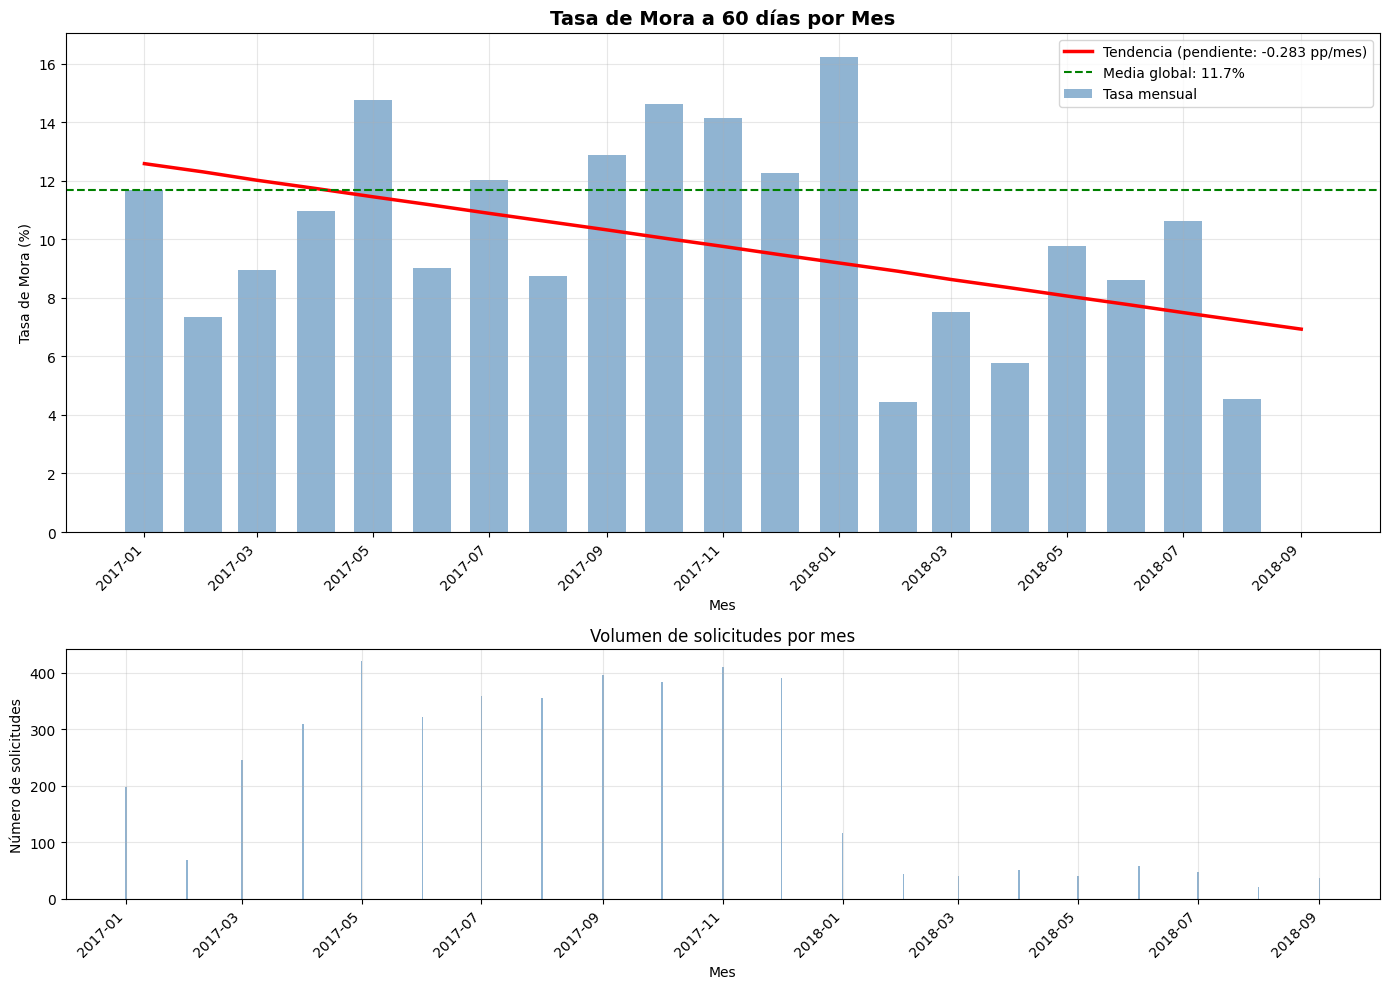


ANÁLISIS TEMPORAL MENSUAL - MORA A 60 DÍAS

📅 Período analizado:
   Desde: January 2017
   Hasta: September 2018
   Total meses: 21

📈 Tendencia:
   Pendiente: -0.2826 puntos porcentuales por mes
   Variación anual: -3.39 pp/año
   R²: 0.1934
   p-value: 0.046036
   ✅ Tendencia BAJISTA significativa (la morosidad está DISMINUYENDO)

📊 Estadísticas mensuales:
   Tasa media: 9.76%
   Mediana: 9.76%
   Desviación estándar: 3.99pp

🔴 Mayor morosidad: January 2018 (16.2%, n=117)
🟢 Menor morosidad: September 2018 (0.0%, n=37)

📆 Tasa de morosidad por mes del año:
   January: 13.38% (n=314)
   February: 6.19% (n=113)
   March: 8.74% (n=286)
   April: 10.22% (n=362)
   May: 14.32% (n=461)
   June: 8.95% (n=380)
   July: 11.85% (n=405)
   August: 8.49% (n=377)
   September: 11.78% (n=433)
   October: 14.62% (n=383)
   November: 14.15% (n=410)
   December: 12.28% (n=391)

   Test Chi-cuadrado (mes vs morosidad): p-value = 0.019644
   ✅ El mes del año SÍ afecta significativamente la morosidad


In [ ]:
# ============================================
# 1. CORREGIR EL PARSING DE FECHAS
# ============================================

# Opción A: Si FFECHA es numérico (201710)
df_clean['FFECHA'] = pd.to_datetime(df_clean['FFECHA'], format='%Y%m', errors='coerce')

# Opción B: Si FFECHA es string ('201710')
# df_clean['FFECHA'] = pd.to_datetime(df_clean['FFECHA'].astype(str), format='%Y%m', errors='coerce')

# Verificar resultado
print("=== VERIFICACIÓN ===")
print(f"Rango de fechas: {df_clean['FFECHA'].min()} a {df_clean['FFECHA'].max()}")
print(f"Meses únicos: {df_clean['FFECHA'].dt.month.nunique()}")
print(f"Años únicos: {df_clean['FFECHA'].dt.year.nunique()}")
print(f"Total meses: {df_clean['FFECHA'].nunique()}")

# ============================================
# 2. ANÁLISIS MENSUAL (NO DIARIO)
# ============================================

# Agrupar por mes
monthly_data = df_clean.groupby(df_clean['FFECHA'].dt.to_period('M')).agg(
    total_solicitudes=('Mora60', 'count'),
    mora60_count=('Mora60', 'sum')
).reset_index()

monthly_data['tasa_Mora60'] = (monthly_data['mora60_count'] / monthly_data['total_solicitudes']) * 100
monthly_data['FFECHA'] = monthly_data['FFECHA'].dt.to_timestamp()

# Calcular tendencia (usando meses numéricos)
x_numeric = np.arange(len(monthly_data))
slope, intercept, r_value, p_value, std_err = stats.linregress(x_numeric, monthly_data['tasa_Mora60'])
monthly_data['tendencia'] = intercept + slope * x_numeric

# ============================================
# 3. VISUALIZACIÓN MENSUAL
# ============================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# Gráfico principal
ax1.bar(monthly_data['FFECHA'], monthly_data['tasa_Mora60'], 
        alpha=0.6, color='steelblue', label='Tasa mensual', width=20)

ax1.plot(monthly_data['FFECHA'], monthly_data['tendencia'], 
         'r-', linewidth=2.5, label=f'Tendencia (pendiente: {slope:.3f} pp/mes)')

# Media global
media_global = df_clean['Mora60'].mean() * 100
ax1.axhline(y=media_global, color='green', linestyle='--', 
            linewidth=1.5, label=f'Media global: {media_global:.1f}%')

ax1.set_title('Tasa de Mora a 60 días por Mes', fontsize=14, fontweight='bold')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Tasa de Mora (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Rotar etiquetas del eje X
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Gráfico de volumen
ax2.bar(monthly_data['FFECHA'], monthly_data['total_solicitudes'], 
        alpha=0.6, color='steelblue')
ax2.set_xlabel('Mes')
ax2.set_ylabel('Número de solicitudes')
ax2.set_title('Volumen de solicitudes por mes')
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()

# Guardar o mostrar
try:
    plt.show(block=True)
except:
    plt.savefig('analisis_mensual_mora60.png', dpi=100, bbox_inches='tight')
    print("✅ Gráfico guardado como 'analisis_mensual_mora60.png'")

# ============================================
# 4. ESTADÍSTICAS CLAVE
# ============================================

print("\n" + "="*60)
print("ANÁLISIS TEMPORAL MENSUAL - MORA A 60 DÍAS")
print("="*60)

print(f"\n📅 Período analizado:")
print(f"   Desde: {monthly_data['FFECHA'].min().strftime('%B %Y')}")
print(f"   Hasta: {monthly_data['FFECHA'].max().strftime('%B %Y')}")
print(f"   Total meses: {len(monthly_data)}")

print(f"\n📈 Tendencia:")
print(f"   Pendiente: {slope:.4f} puntos porcentuales por mes")
print(f"   Variación anual: {slope * 12:.2f} pp/año")
print(f"   R²: {r_value**2:.4f}")
print(f"   p-value: {p_value:.6f}")

if p_value < 0.05:
    if slope > 0:
        print("   ✅ Tendencia ALCISTA significativa (la morosidad está AUMENTANDO)")
    else:
        print("   ✅ Tendencia BAJISTA significativa (la morosidad está DISMINUYENDO)")
else:
    print("   ⚠️ Tendencia NO significativa estadísticamente")

print(f"\n📊 Estadísticas mensuales:")
print(f"   Tasa media: {monthly_data['tasa_Mora60'].mean():.2f}%")
print(f"   Mediana: {monthly_data['tasa_Mora60'].median():.2f}%")
print(f"   Desviación estándar: {monthly_data['tasa_Mora60'].std():.2f}pp")

# Mejor y peor mes
max_month = monthly_data.loc[monthly_data['tasa_Mora60'].idxmax()]
min_month = monthly_data.loc[monthly_data['tasa_Mora60'].idxmin()]
print(f"\n🔴 Mayor morosidad: {max_month['FFECHA'].strftime('%B %Y')} ({max_month['tasa_Mora60']:.1f}%, n={max_month['total_solicitudes']})")
print(f"🟢 Menor morosidad: {min_month['FFECHA'].strftime('%B %Y')} ({min_month['tasa_Mora60']:.1f}%, n={min_month['total_solicitudes']})")

# ============================================
# 5. ANÁLISIS ADICIONALES RELEVANTES
# ============================================

# Estacionalidad por mes del año
df_clean['mes'] = df_clean['FFECHA'].dt.month
df_clean['nombre_mes'] = df_clean['FFECHA'].dt.month_name()

tasa_por_mes = df_clean.groupby('nombre_mes')['Mora60'].agg(['mean', 'count'])
tasa_por_mes['tasa'] = tasa_por_mes['mean'] * 100

print("\n📆 Tasa de morosidad por mes del año:")
meses_orden = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
for mes in meses_orden:
    if mes in tasa_por_mes.index:
        print(f"   {mes}: {tasa_por_mes.loc[mes, 'tasa']:.2f}% (n={tasa_por_mes.loc[mes, 'count']})")

# Test estadístico para estacionalidad
from scipy.stats import chi2_contingency
tabla_mes = pd.crosstab(df_clean['mes'], df_clean['Mora60'])
chi2, p_mes, dof, expected = chi2_contingency(tabla_mes)
print(f"\n   Test Chi-cuadrado (mes vs morosidad): p-value = {p_mes:.6f}")
if p_mes < 0.05:
    print("   ✅ El mes del año SÍ afecta significativamente la morosidad")
else:
    print("   ❌ No hay evidencia de efecto estacional por mes")

**Lo que nos dice el análisis temporal**

- Tendencia bajista significativa (p=0.046): La tasa de mora cae de ~12.6% en enero 2017 a ~7% en septiembre 2018, con una pendiente de -0.28 pp/mes. Esto significa que la población está cambiando en el tiempo — los clientes más recientes tienen un perfil de riesgo diferente a los más antiguos.

- Estacionalidad significativa (Chi² p=0.019): Enero, mayo, octubre y noviembre tienen mora alta (13-16%), mientras febrero, marzo y junio tienen mora baja (6-9%). El mes del año sí importa.

- Volumen irregular: Hay meses con n=37 y meses con n=461 — el dataset no está balanceado temporalmente, lo que afecta cómo el modelo aprende de cada período.

# 3. Distribución del target (Mora60)

Dataset limpio : 4,315 registros | 24 columnas
Tasa de default: 11.68%  (Malos: 504 | Buenos: 3811)



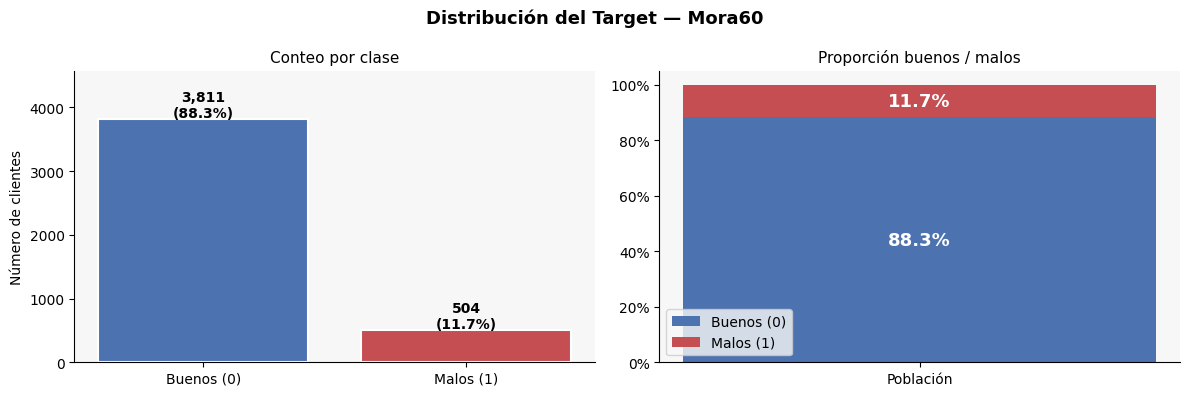

✓ Gráfico 1: distribución del target


In [19]:
# =============================================================================
# CONFIGURACIÓN VISUAL
# =============================================================================
 
COLOR_BUENO = "#4C72B0"
COLOR_MALO  = "#C44E52"
PALETTE     = [COLOR_BUENO, COLOR_MALO]
 
plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#F7F7F7",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 11,
    "axes.labelsize"    : 10,
})

TARGET       = "Mora60"
TASA_GLOBAL  = df_clean[TARGET].mean()
 
print(f"Dataset limpio : {df_clean.shape[0]:,} registros | {df_clean.shape[1]} columnas")
print(f"Tasa de default: {TASA_GLOBAL:.2%}  (Malos: {df_clean[TARGET].sum()} | Buenos: {(df_clean[TARGET]==0).sum()})\n")
 
# Variables a analizar
EXCLUIR   = ["ID", "FFECHA", "Mora30", "Mora60"]
NUM_COLS  = [c for c in df_clean.select_dtypes(include=np.number).columns if c not in EXCLUIR]
CAT_COLS  = ["OCUPACION", "TIPCONTRATO", "Estado_Civil", "Genero", "Nivel_Academico", "Tipo_Vivienda"]
 
# Variables numéricas para gráficos (excluye binarias y flags)
NUM_PLOT  = [c for c in NUM_COLS
             if c not in ["flag_arriendo_imputado", "flag_actividad_inconsistente",
                          "ExperienciaSectorFinanciero"]]

# =============================================================================
# 1. DISTRIBUCIÓN DEL TARGET
# =============================================================================
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribución del Target — Mora60", fontsize=13, fontweight="bold")
 
conteo = df_clean[TARGET].value_counts().sort_index()
axes[0].bar(["Buenos (0)", "Malos (1)"], conteo.values,
            color=PALETTE, edgecolor="white", linewidth=1.5)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 30, f"{v:,}\n({v/len(df_clean):.1%})",
                 ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Conteo por clase")
axes[0].set_ylabel("Número de clientes")
axes[0].set_ylim(0, conteo.max() * 1.2)
 
axes[1].bar(["Población"], [1 - TASA_GLOBAL], color=COLOR_BUENO, label="Buenos (0)")
axes[1].bar(["Población"], [TASA_GLOBAL], bottom=[1 - TASA_GLOBAL],
            color=COLOR_MALO, label="Malos (1)")
axes[1].text(0, (1 - TASA_GLOBAL) / 2, f"{1-TASA_GLOBAL:.1%}",
             ha="center", va="center", color="white", fontsize=13, fontweight="bold")
axes[1].text(0, 1 - TASA_GLOBAL + TASA_GLOBAL / 2, f"{TASA_GLOBAL:.1%}",
             ha="center", va="center", color="white", fontsize=13, fontweight="bold")
axes[1].set_title("Proporción buenos / malos")
axes[1].legend()
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
 
plt.tight_layout()
plt.savefig("01_target_distribucion.png", dpi=150, bbox_inches="tight")
#plt.close()
plt.show()
print("✓ Gráfico 1: distribución del target")

La variable objetivo presenta un desbalance moderado: 88.3% de buenos pagadores (3,811 clientes) frente a 11.7% de incumplimientos (504 clientes). Esta proporción es característica de productos de crédito de consumo y no representa un desbalance severo que obligue a técnicas agresivas de resampling como SMOTE. Sin embargo, sí implica que la métrica de evaluación principal debe ser el AUC-ROC y el KS, no el accuracy, ya que un modelo que prediga siempre "bueno" tendría 88% de accuracy sin ningún poder predictivo real.

# 4. EDA variables numéricas

## 4.1 Distribución por variable vs target

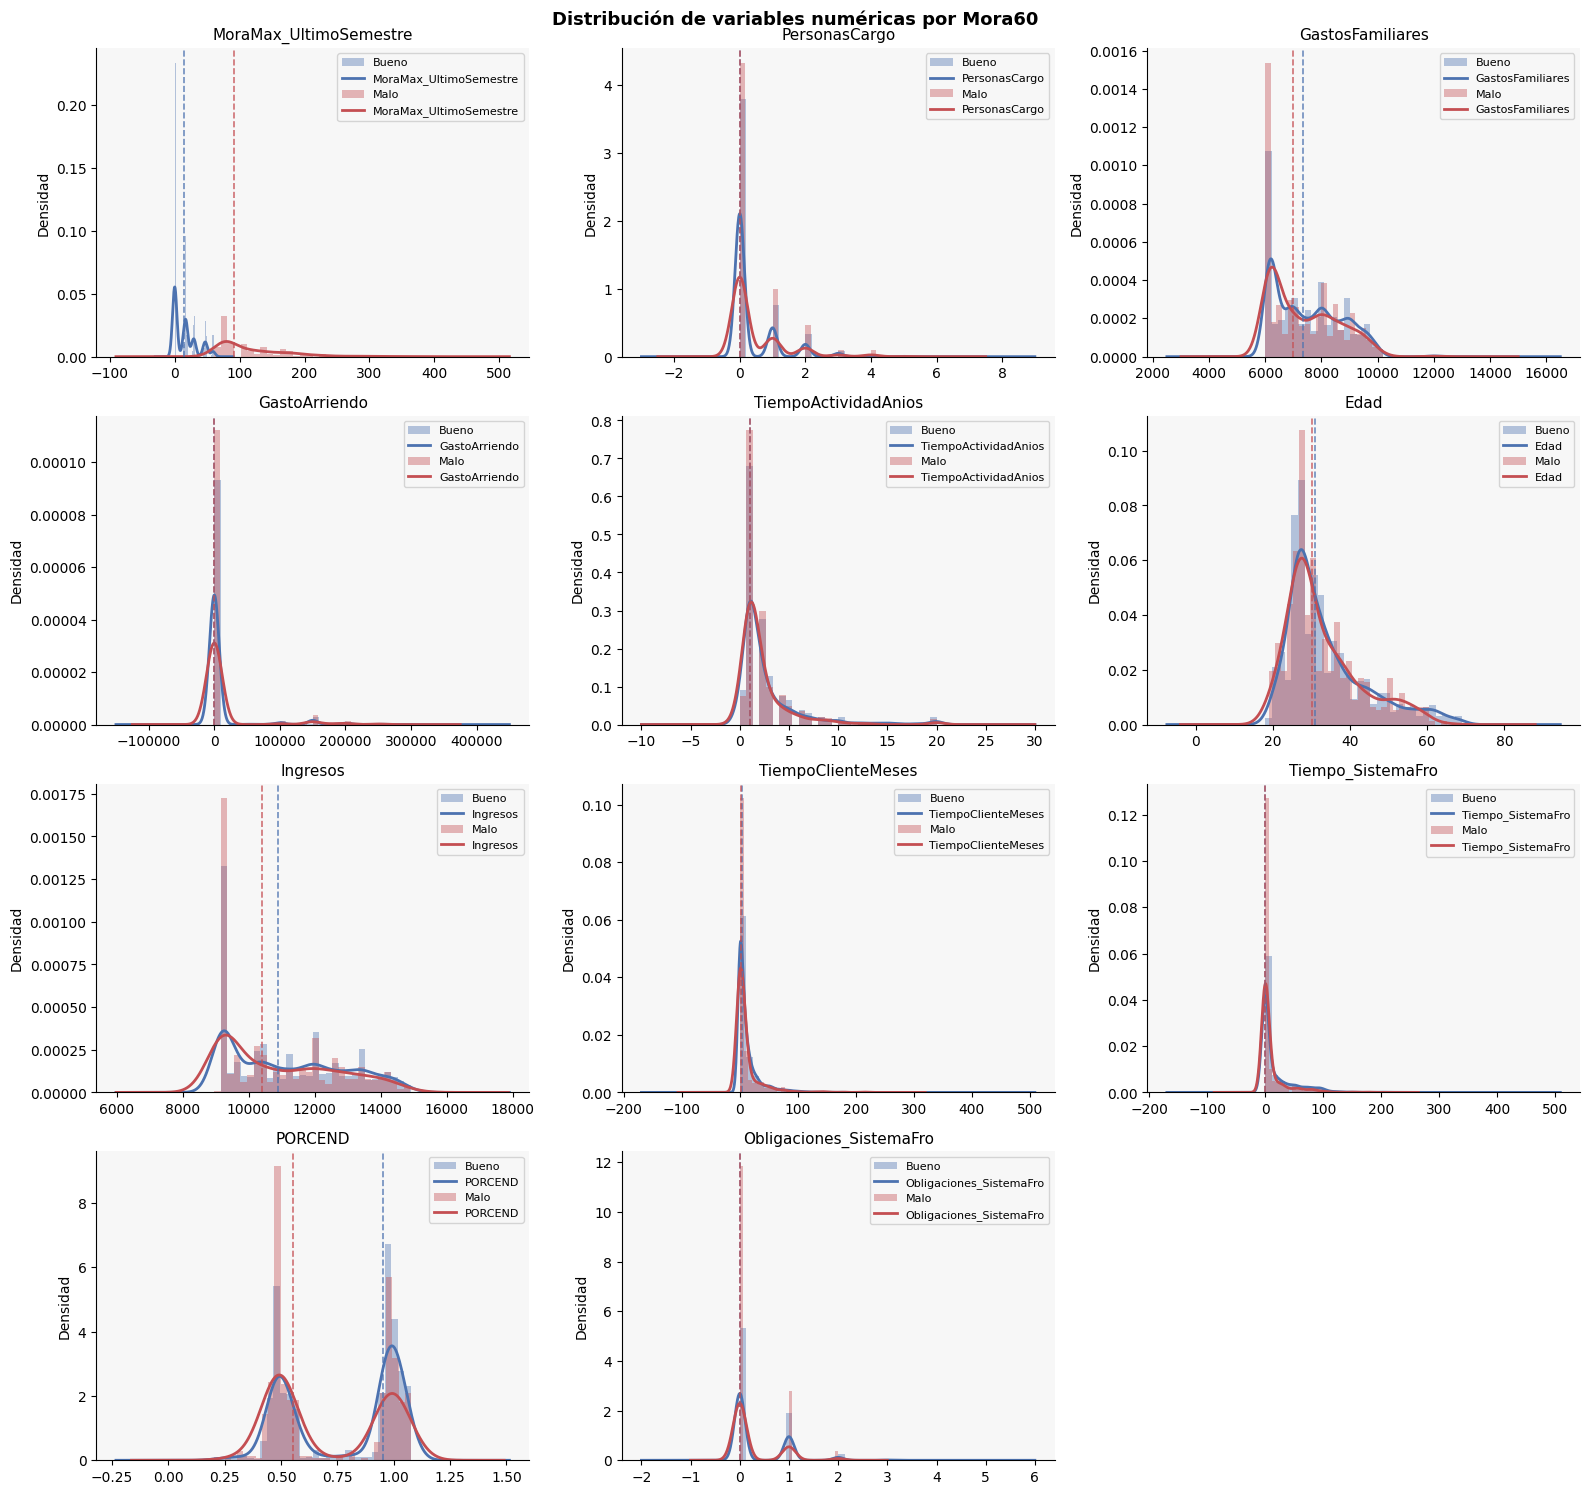

✓ Gráfico 2a: distribuciones numéricas vs target


In [20]:
# =============================================================================
# DISTRIBUCIONES NUMÉRICAS VS TARGET
# =============================================================================
 
n_cols = 3
n_rows = int(np.ceil(len(NUM_PLOT) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.8))
fig.suptitle("Distribución de variables numéricas por Mora60",
             fontsize=13, fontweight="bold")
axes = axes.flatten()
 
for i, col in enumerate(NUM_PLOT):
    ax = axes[i]
    for val, label, color in zip([0, 1], ["Bueno", "Malo"], PALETTE):
        subset = df_clean[df_clean[TARGET] == val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.4, color=color, density=True,
                label=label, edgecolor="none")
        subset.plot.kde(ax=ax, color=color, linewidth=2)
    # Medianas
    med_b = df_clean[df_clean[TARGET] == 0][col].median()
    med_m = df_clean[df_clean[TARGET] == 1][col].median()
    ax.axvline(med_b, color=COLOR_BUENO, linestyle="--", linewidth=1.2, alpha=0.8)
    ax.axvline(med_m, color=COLOR_MALO,  linestyle="--", linewidth=1.2, alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.tight_layout()
plt.savefig("02_num_distribuciones.png", dpi=150, bbox_inches="tight")
#plt.close()
plt.show()
print("✓ Gráfico 2a: distribuciones numéricas vs target")

Las variables con mayor separación visual entre la distribución de buenos y malos son ```Tiempo_SistemaFro``` y ```TiempoClienteMeses```: los clientes malos tienden a tener menor tiempo en el sistema, lo que sugiere que **la antigüedad en la entidad es una señal de confiabilidad**. ```PORCEND``` muestra que los clientes malos se concentran en valores más altos de endeudamiento, confiriendo poder predictivo a esta variable. ```MoraMax_UltimoSemestre``` tiene separación perfecta — señal de data leakage confirmada, se excluye del modelo. Variables como ```Ingresos``` y ```GastosFamiliares``` muestran distribuciones casi idénticas entre clases, consistente con su correlación mecánica y bajo IV individual. 

## 4.2 Boxplots por target (detección de outliers)

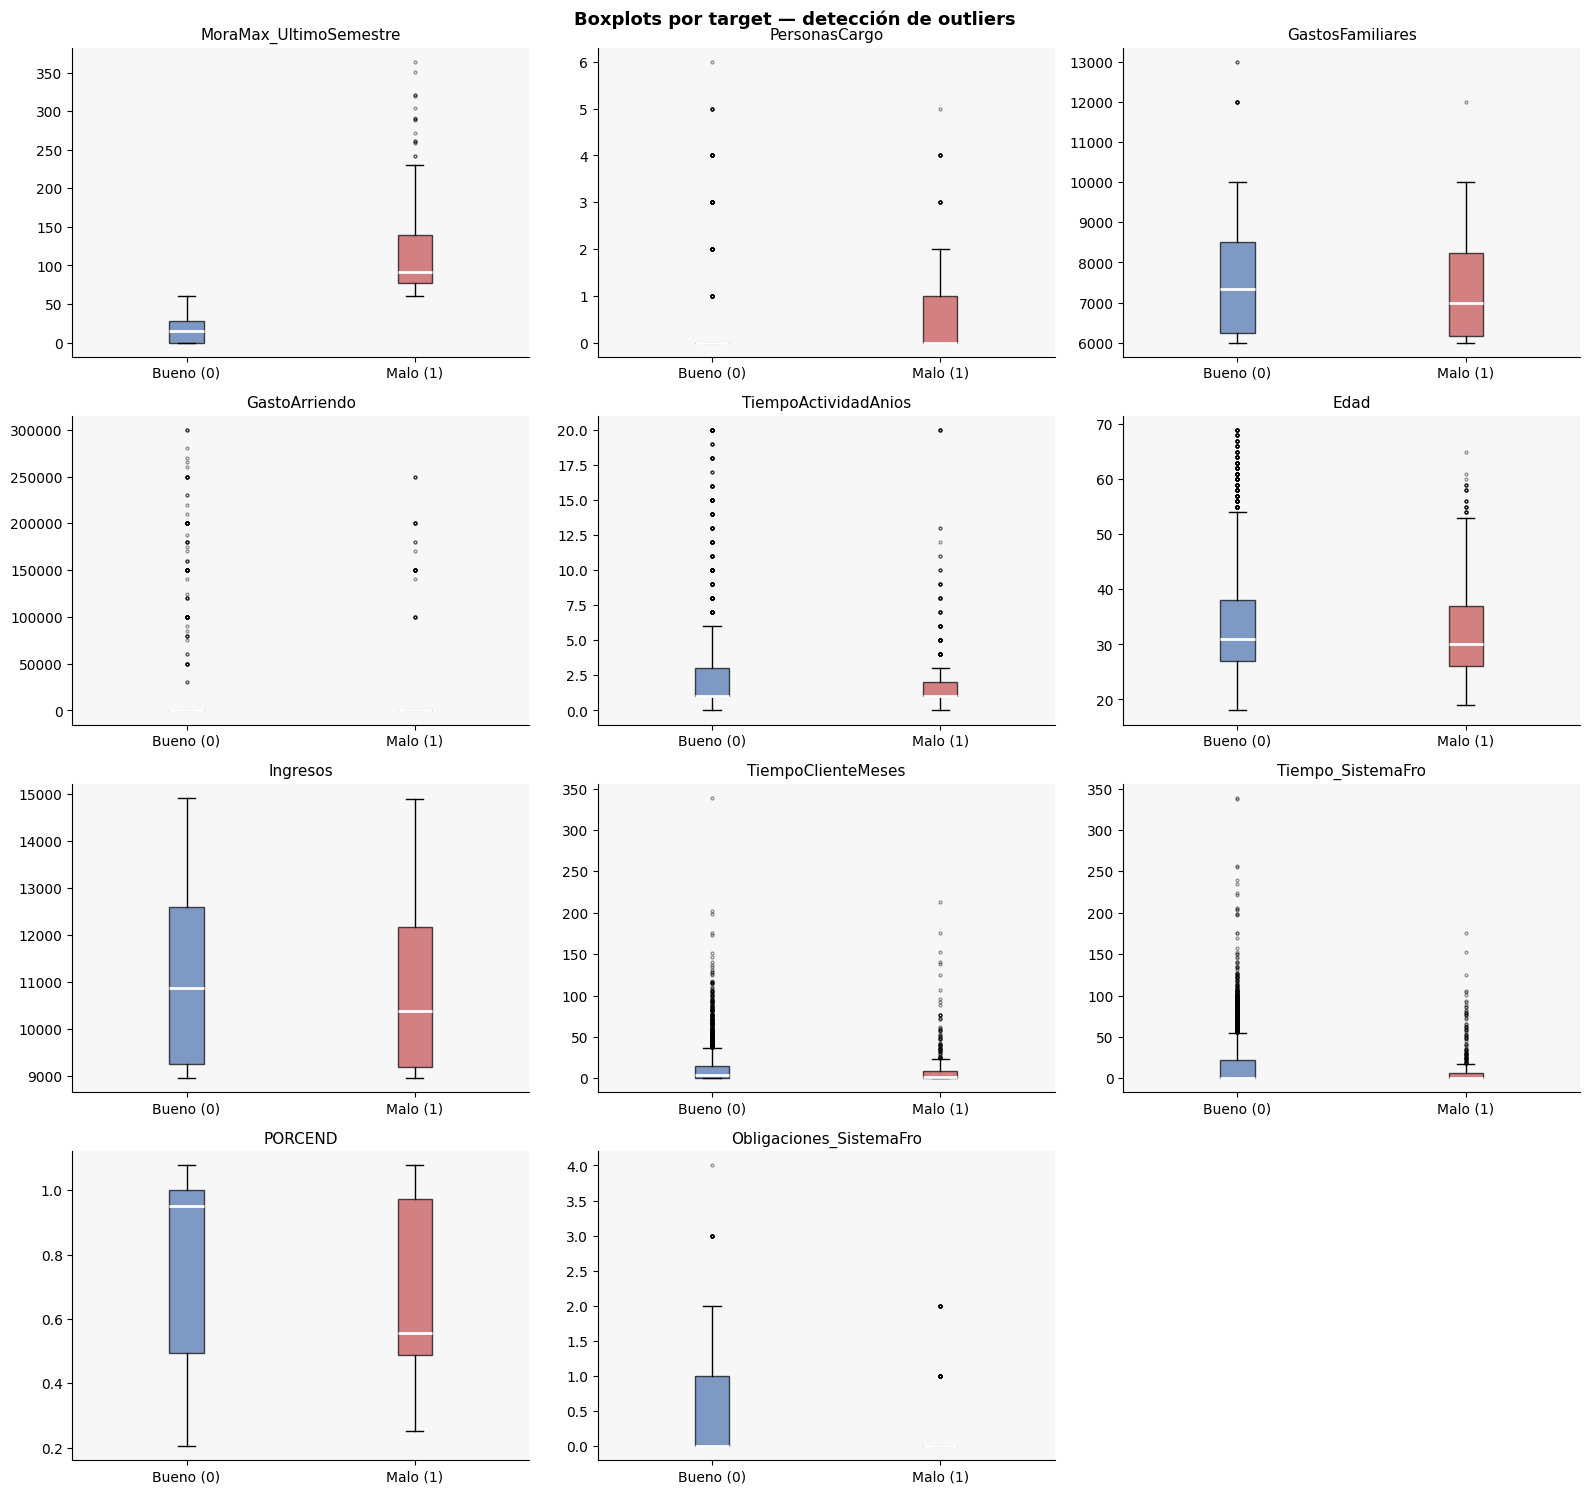

✓ Gráfico 2b: boxplots por target


In [22]:
# =============================================================================
# BOXPLOTS POR TARGET
# =============================================================================
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.8))
fig.suptitle("Boxplots por target — detección de outliers",
             fontsize=13, fontweight="bold")
axes = axes.flatten()
 
for i, col in enumerate(NUM_PLOT):
    ax = axes[i]
    data_plot = [
        df_clean[df_clean[TARGET] == 0][col].dropna().values,
        df_clean[df_clean[TARGET] == 1][col].dropna().values,
    ]
    bp = ax.boxplot(data_plot, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.4))
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(["Bueno (0)", "Malo (1)"])
    ax.set_title(col)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.tight_layout()
plt.savefig("03_boxplots_outliers.png", dpi=150, bbox_inches="tight")
#plt.close()
plt.show()
print("✓ Gráfico 2b: boxplots por target")

Los boxplots confirman los hallazgos de las distribuciones. ```Tiempo_SistemaFro``` y ```TiempoClienteMeses``` presentan medianas claramente distintas entre buenos y malos. Se observa una cantidad importante de outliers en la cola superior de ```TiempoClienteMeses``` en el grupo de buenos pagadores — clientes con larga trayectoria que prácticamente no incumplen. ```PORCEND``` muestra que los malos tienen una mediana de endeudamiento superior, aunque los rangos se solapan, lo que explica su IV débil-moderado. ```Edad``` y ```TiempoActividadAnios``` tienen boxplots muy similares entre clases, señal de bajo poder discriminante individual.

**Razonamiento de fondo tratamiento outliers**

```Edad```, ```PORCEND```, ```Ingresos```: Los outliers tienen una tasa de mora similar o menor a la población general — son observaciones válidas con comportamiento coherente, no ruido. Winsorizarlos eliminaría información real sin beneficio.

```TiempoClienteMeses``` y ```Tiempo_SistemaFro```: Aquí sí hay algo interesante pero al revés de lo esperado. Los outliers de ```TiempoClienteMeses``` (clientes con > 100 meses) tienen mora más **alta** (15.9%), y los de ```Tiempo_SistemaFro``` tienen mora más **baja** (6.8%). Ambos patrones son informativos — winsorizarlos aplastaría una señal real. La decisión correcta aquí no es winsorizar sino **transformar con log o raíz cuadrada** para comprimir la escala sin perder la señal de los extremos.

```TiempoActividadAnios```: Ya fue tratado en el script de limpieza con cap en p99=20.

No aplicar winsorización global 1%-99%. En este dataset los outliers no son ruido — son perfiles extremos reales (clientes muy antiguos, muy jóvenes, muy endeudados) que el modelo debe aprender a identificar. La estrategia correcta es:

- **Transformación logarítmica** en ```TiempoClienteMeses``` y ```Tiempo_SistemaFro``` (distribuciones muy sesgadas a la derecha con muchos ceros) — esto lo manejamos en el Feature Engineering
- Los modelos basados en árboles como LightGBM son naturalmente robustos a outliers porque hacen splits por umbrales, no por distancias — lo que reduce aún más la necesidad de winsorización

## 4.3 Matriz de correlación

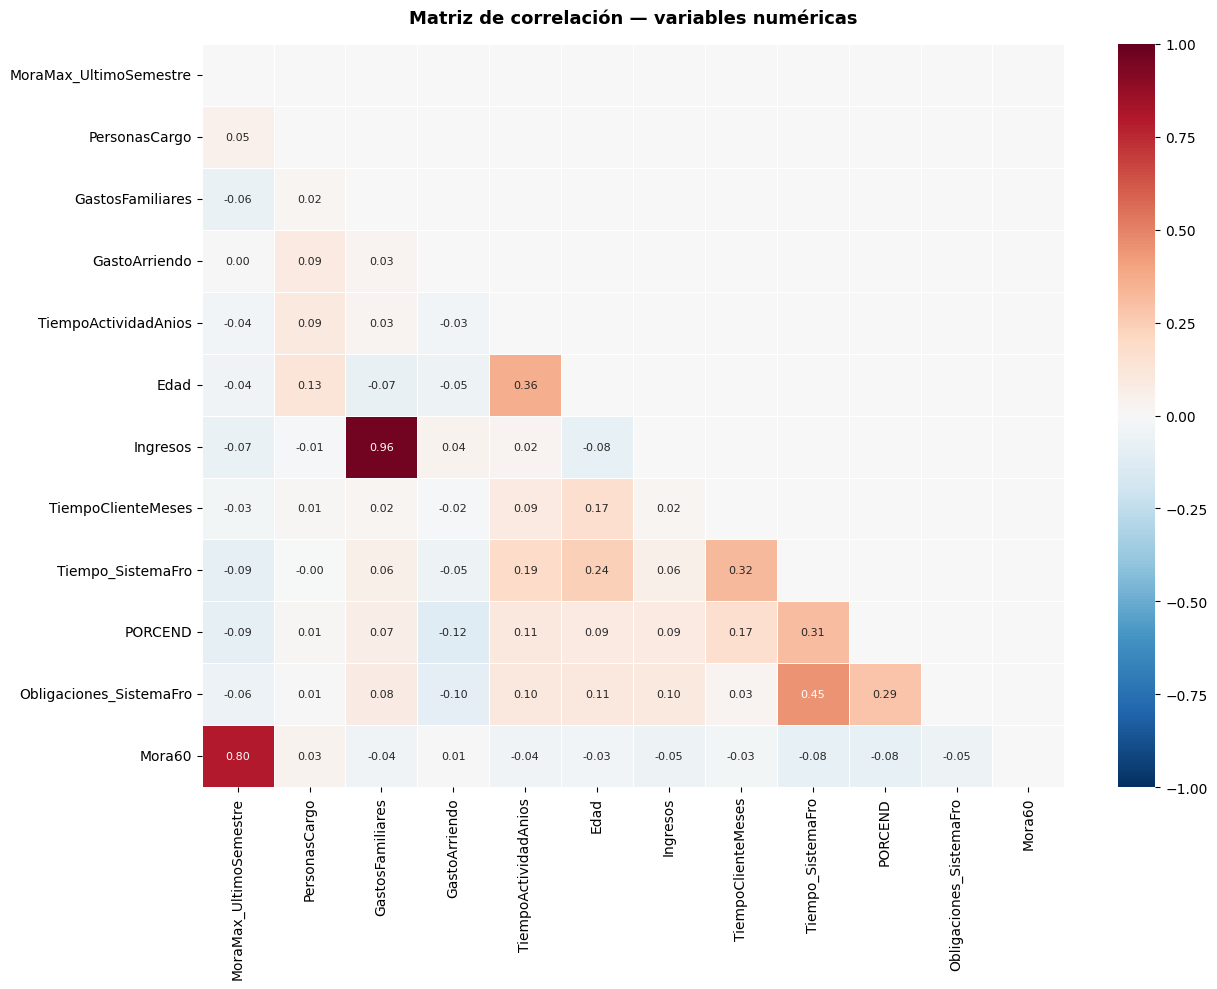

✓ Gráfico 2c: matriz de correlación


In [24]:
# =============================================================================
# MATRIZ DE CORRELACIÓN
# =============================================================================
 
CORR_COLS = NUM_PLOT + ["Mora60"]
corr = df_clean[CORR_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
 
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Matriz de correlación — variables numéricas",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("04_correlacion.png", dpi=150, bbox_inches="tight")
#plt.close()
plt.show()
print("✓ Gráfico 2c: matriz de correlación")

Se confirman dos hallazgos críticos. Primero, ```GastosFamiliares``` e ```Ingresos``` tienen una correlación de **0.96**, consecuencia del cálculo automático detectado en la calidad de datos (67% fijo). Incluir ambas en el modelo generaría multicolinealidad severa — se conservará solo una o se reemplazarán por el ratio de capacidad de pago en el Feature Engineering. Segundo, ```Tiempo_SistemaFro``` y ```TiempoClienteMeses``` correlacionan en 0.32, nivel moderado que no representa multicolinealidad problemática — ambas pueden coexistir en el modelo. El único par crítico sigue siendo ```GastosFamiliares``` / ```Ingresos``` con 0.96.

# 5. EDA variables categóricas

## 5.1 Tasa de default por categoría

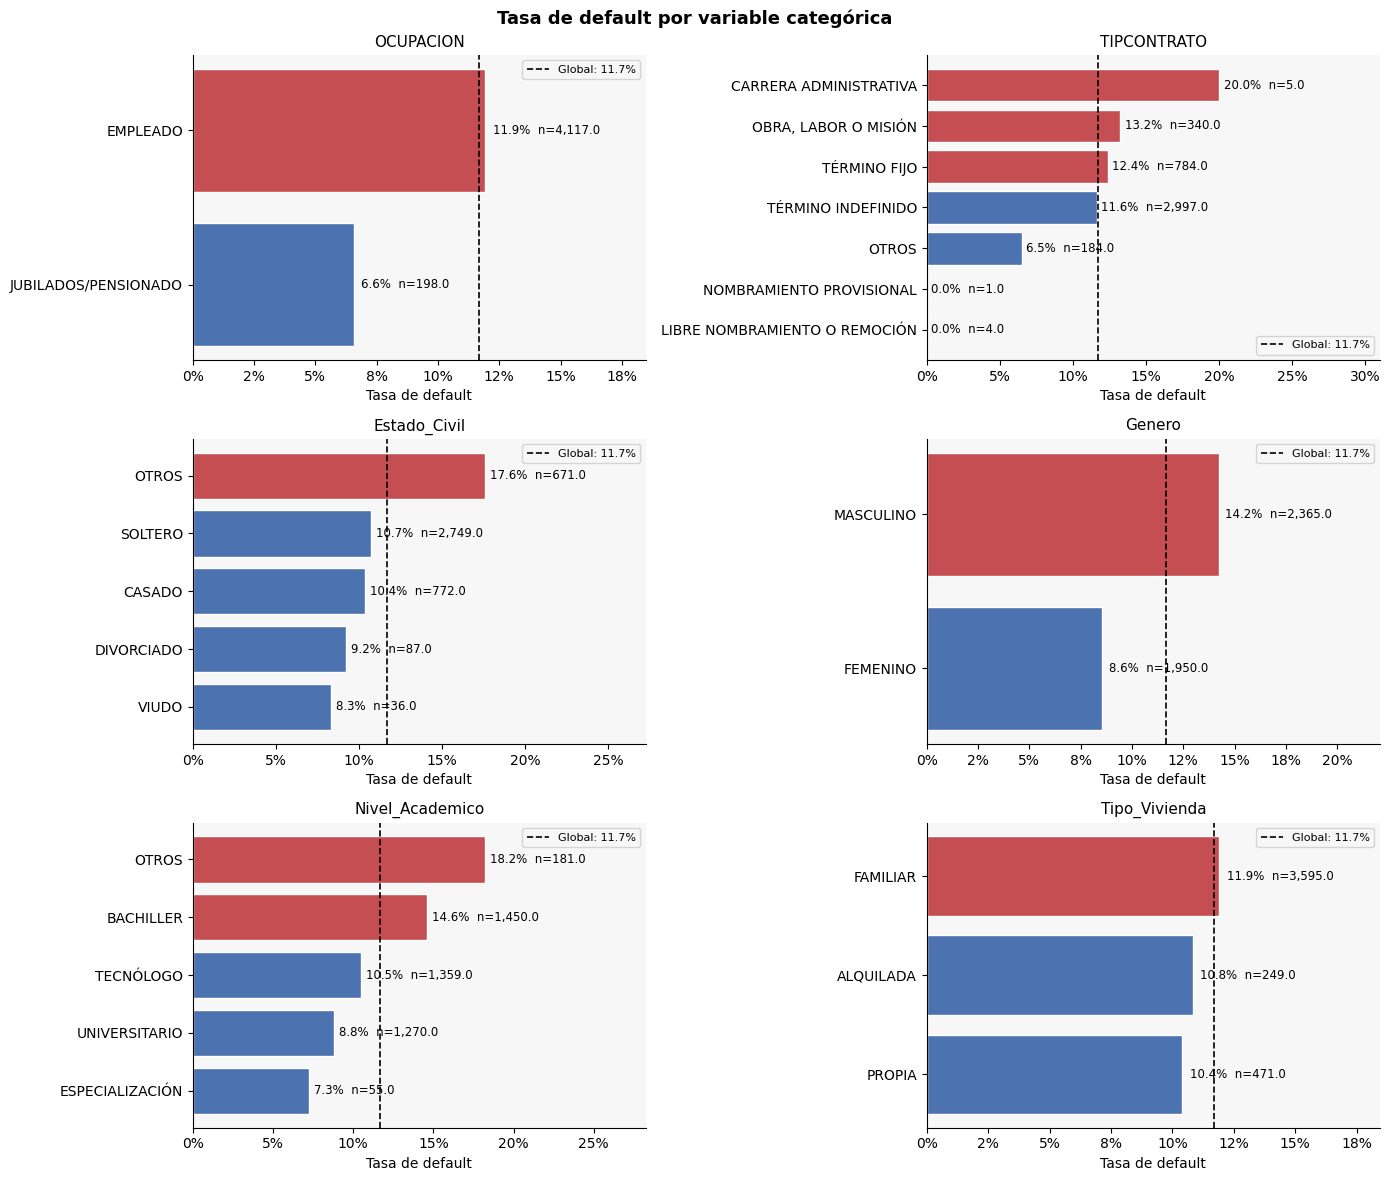

✓ Gráfico 3: categóricas vs tasa de default


In [26]:
# =============================================================================
# EDA CATEGÓRICAS — tasa de default por categoría
# =============================================================================
 
n_cols_c = 2
n_rows_c = int(np.ceil(len(CAT_COLS) / n_cols_c))
fig, axes = plt.subplots(n_rows_c, n_cols_c, figsize=(14, n_rows_c * 4))
fig.suptitle("Tasa de default por variable categórica",
             fontsize=13, fontweight="bold")
axes = axes.flatten()
 
for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    stats = (df_clean.groupby(col, observed=True)[TARGET]
             .agg(["mean", "count"])
             .rename(columns={"mean": "tasa", "count": "n"})
             .sort_values("tasa", ascending=True))
 
    colores_bar = [COLOR_MALO if t > TASA_GLOBAL else COLOR_BUENO for t in stats["tasa"]]
    bars = ax.barh(stats.index, stats["tasa"], color=colores_bar,
                   edgecolor="white", linewidth=1)
    ax.axvline(TASA_GLOBAL, color="black", linestyle="--", linewidth=1.2,
               label=f"Global: {TASA_GLOBAL:.1%}")
 
    for bar, (idx, row) in zip(bars, stats.iterrows()):
        ax.text(row["tasa"] + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{row['tasa']:.1%}  n={row['n']:,}",
                va="center", fontsize=8.5)
 
    ax.set_title(col)
    ax.set_xlabel("Tasa de default")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_xlim(0, stats["tasa"].max() * 1.55)
    ax.legend(fontsize=8)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.tight_layout()
plt.savefig("05_categoricas_default.png", dpi=150, bbox_inches="tight")
#plt.close()
plt.show()
print("✓ Gráfico 3: categóricas vs tasa de default")

```Genero``` muestra la diferencia más marcada: las mujeres tienen una tasa de default de ~8% frente a ~14% de los hombres — diferencia que deberá documentarse con cuidado por implicaciones regulatorias en modelos de crédito. ```Nivel_Academico``` revela que clientes con especialización tienen mora más baja (~7%), mientras bachilleres superan el 13%. ```Estado_Civil``` muestra que viudos y divorciados tienen tasas más altas que casados y solteros. ```TIPCONTRATO``` y ```OCUPACION``` tienen diferencias menores y por debajo del umbral de IV útil. ```Tipo_Vivienda``` no discrimina prácticamente nada — consistente con su IV cercano a cero.

# 6. Cálculo de Information Value (IV) — todas las variables

In [28]:
# =============================================================================
# CÁLCULO DE INFORMATION VALUE (IV)
# =============================================================================
# Escala de interpretación estándar en scorecards:
#   < 0.02   → Sin poder predictivo  → descartar
#   0.02–0.1 → Poder débil           → considerar con cautela
#   0.1–0.3  → Poder moderado        → incluir
#   0.3–0.5  → Poder fuerte          → incluir
#   > 0.5    → Sospechoso            → revisar data leakage
# =============================================================================
 
def _iv_desde_grupos(df_tmp: pd.DataFrame, bin_col: str) -> tuple:
    """Núcleo del cálculo IV: agrupa, calcula WoE e IV por bin."""
    total_b = (df_tmp["target"] == 0).sum()
    total_m = (df_tmp["target"] == 1).sum()
 
    filas = []
    for bin_val, grp in df_tmp.groupby(bin_col, observed=True):
        n_b = (grp["target"] == 0).sum()
        n_m = (grp["target"] == 1).sum()
        dist_b = max(n_b, 0.5) / total_b   # suavizado anti-log(0)
        dist_m = max(n_m, 0.5) / total_m
        woe    = np.log(dist_b / dist_m)
        filas.append({
            "bin": str(bin_val), "n": len(grp),
            "n_buenos": n_b, "n_malos": n_m,
            "dist_b": dist_b, "dist_m": dist_m,
            "woe": woe, "iv": (dist_b - dist_m) * woe,
        })
 
    df_res = pd.DataFrame(filas)
    return df_res["iv"].sum(), df_res
 
 
def iv_numerica(serie, target, n_bins=10):
    df_t = pd.DataFrame({"var": serie, "target": target}).dropna()
    try:
        df_t["bin"] = pd.qcut(df_t["var"], q=n_bins, duplicates="drop")
    except Exception:
        df_t["bin"] = pd.cut(df_t["var"], bins=n_bins, duplicates="drop")
    return _iv_desde_grupos(df_t, "bin")
 
 
def iv_categorica(serie, target):
    df_t = pd.DataFrame({"var": serie.astype(str), "target": target}).dropna()
    return _iv_desde_grupos(df_t, "var")
 
 
# --- Calcular para todas las variables ---
resultados_iv = {}
 
for col in NUM_COLS:
    iv_val, det = iv_numerica(df_clean[col], df_clean[TARGET])
    resultados_iv[col] = {"IV": iv_val, "tipo": "numérica", "detalle": det}
 
for col in CAT_COLS:
    iv_val, det = iv_categorica(df_clean[col], df_clean[TARGET])
    resultados_iv[col] = {"IV": iv_val, "tipo": "categórica", "detalle": det}
 
# --- Tabla resumen ---
def clasificar_iv(iv):
    if iv < 0.02:  return "Sin poder predictivo"
    if iv < 0.10:  return "Débil"
    if iv < 0.30:  return "Moderado"
    if iv < 0.50:  return "Fuerte"
    return "Sospechoso"
 
df_iv = (pd.DataFrame([{"variable": k, "IV": v["IV"], "tipo": v["tipo"]}
                        for k, v in resultados_iv.items()])
         .sort_values("IV", ascending=False)
         .reset_index(drop=True))
df_iv["clasificacion"] = df_iv["IV"].apply(clasificar_iv)
 
print("\n" + "="*68)
print("RANKING DE VARIABLES POR INFORMATION VALUE (IV)")
print("="*68)
print(df_iv.to_string(index=False))
print("="*68)


RANKING DE VARIABLES POR INFORMATION VALUE (IV)
                    variable        IV       tipo        clasificacion
      MoraMax_UltimoSemestre 13.214552   numérica           Sospechoso
           Tiempo_SistemaFro  0.108545   numérica             Moderado
          TiempoClienteMeses  0.106882   numérica             Moderado
                     PORCEND  0.093174   numérica                Débil
                      Genero  0.078264 categórica                Débil
             Nivel_Academico  0.071205 categórica                Débil
                Estado_Civil  0.053564 categórica                Débil
                    Ingresos  0.049783   numérica                Débil
            GastosFamiliares  0.038179   numérica                Débil
        TiempoActividadAnios  0.024839   numérica                Débil
                        Edad  0.020826   numérica                Débil
                 TIPCONTRATO  0.017707 categórica Sin poder predictivo
                   OCUPACION

# 7. Ranking final de variables por IV

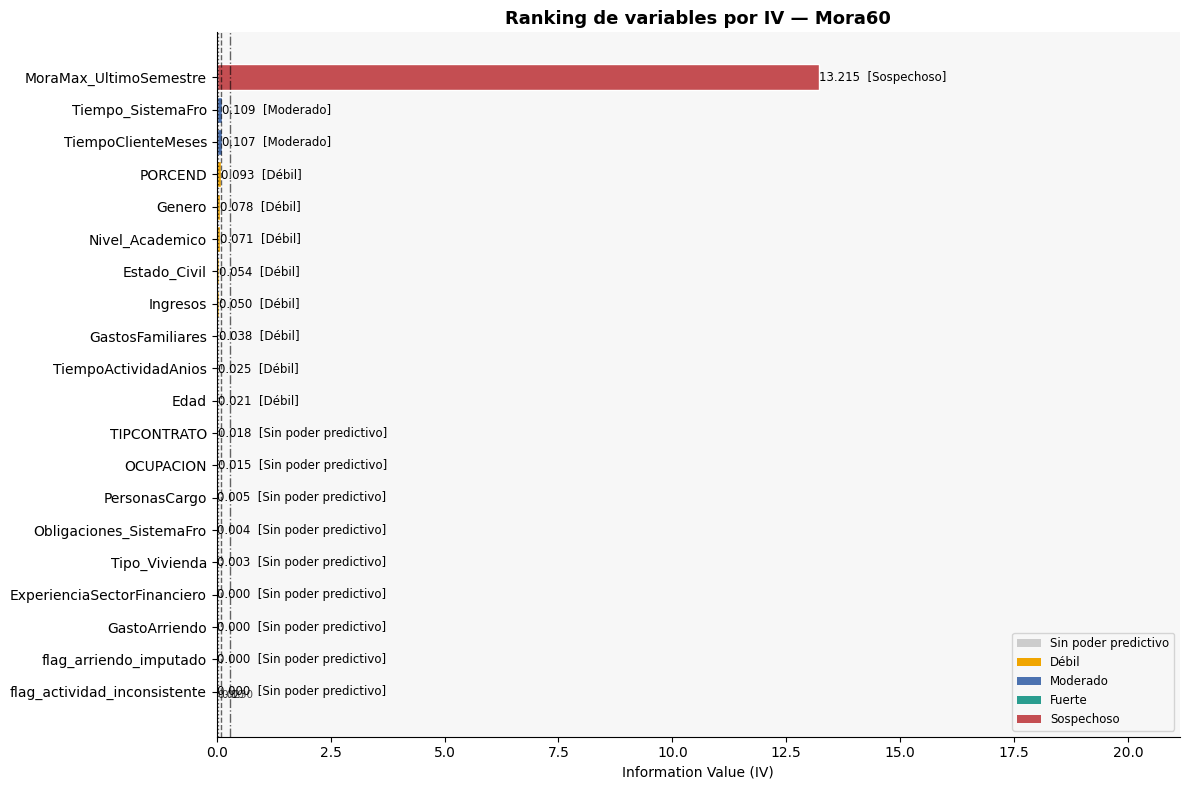

✓ Gráfico 5: ranking IV


In [29]:
# =============================================================================
# GRÁFICO RANKING IV
# =============================================================================
 
COLOR_IV = {
    "Sin poder predictivo": "#CCCCCC",
    "Débil"               : "#F0A500",
    "Moderado"            : COLOR_BUENO,
    "Fuerte"              : "#2A9D8F",
    "Sospechoso"          : COLOR_MALO,
}
 
fig, ax = plt.subplots(figsize=(12, 8))
colores_iv = [COLOR_IV[c] for c in df_iv["clasificacion"]]
bars = ax.barh(df_iv["variable"], df_iv["IV"],
               color=colores_iv, edgecolor="white", linewidth=1)
 
for bar, (_, row) in zip(bars, df_iv.iterrows()):
    ax.text(row["IV"] + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{row["IV"]:.3f}  [{row["clasificacion"]}]',
            va="center", fontsize=8.5)
 
for umbral, label, ls in [(0.02, "0.02", ":"), (0.10, "0.10", "--"), (0.30, "0.30", "-.")]:
    ax.axvline(umbral, color="black", linestyle=ls, linewidth=1, alpha=0.6)
    ax.text(umbral + 0.001, len(df_iv) - 0.8, label,
            fontsize=7.5, color="black", alpha=0.7)
 
ax.set_xlabel("Information Value (IV)")
ax.set_title("Ranking de variables por IV — Mora60",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, df_iv["IV"].max() * 1.6)
 
legend_els = [Patch(facecolor=c, label=l) for l, c in COLOR_IV.items()]
ax.legend(handles=legend_els, loc="lower right", fontsize=8.5)
plt.tight_layout()
plt.savefig("06_iv_ranking.png", dpi=150, bbox_inches="tight")
#plt.close()
plt.show()
print("✓ Gráfico 5: ranking IV")

El ranking confirma la exclusión de ```MoraMax_UltimoSemestre``` (IV=13.2, data leakage). Las únicas variables con IV moderado son ```Tiempo_SistemaFro``` (0.109) y ```TiempoClienteMeses``` (0.107), ambas relacionadas con la antigüedad del cliente. El resto de candidatas tienen IV débil (0.02–0.09), lo que indica que el modelo deberá capturar señales combinadas entre variables más que depender de predictores fuertes individuales. Esto favorece el uso de modelos que detecten interacciones, como **LightGBM**, sobre una regresión logística simple.

# 8. Curvas WoE — top 6 variables

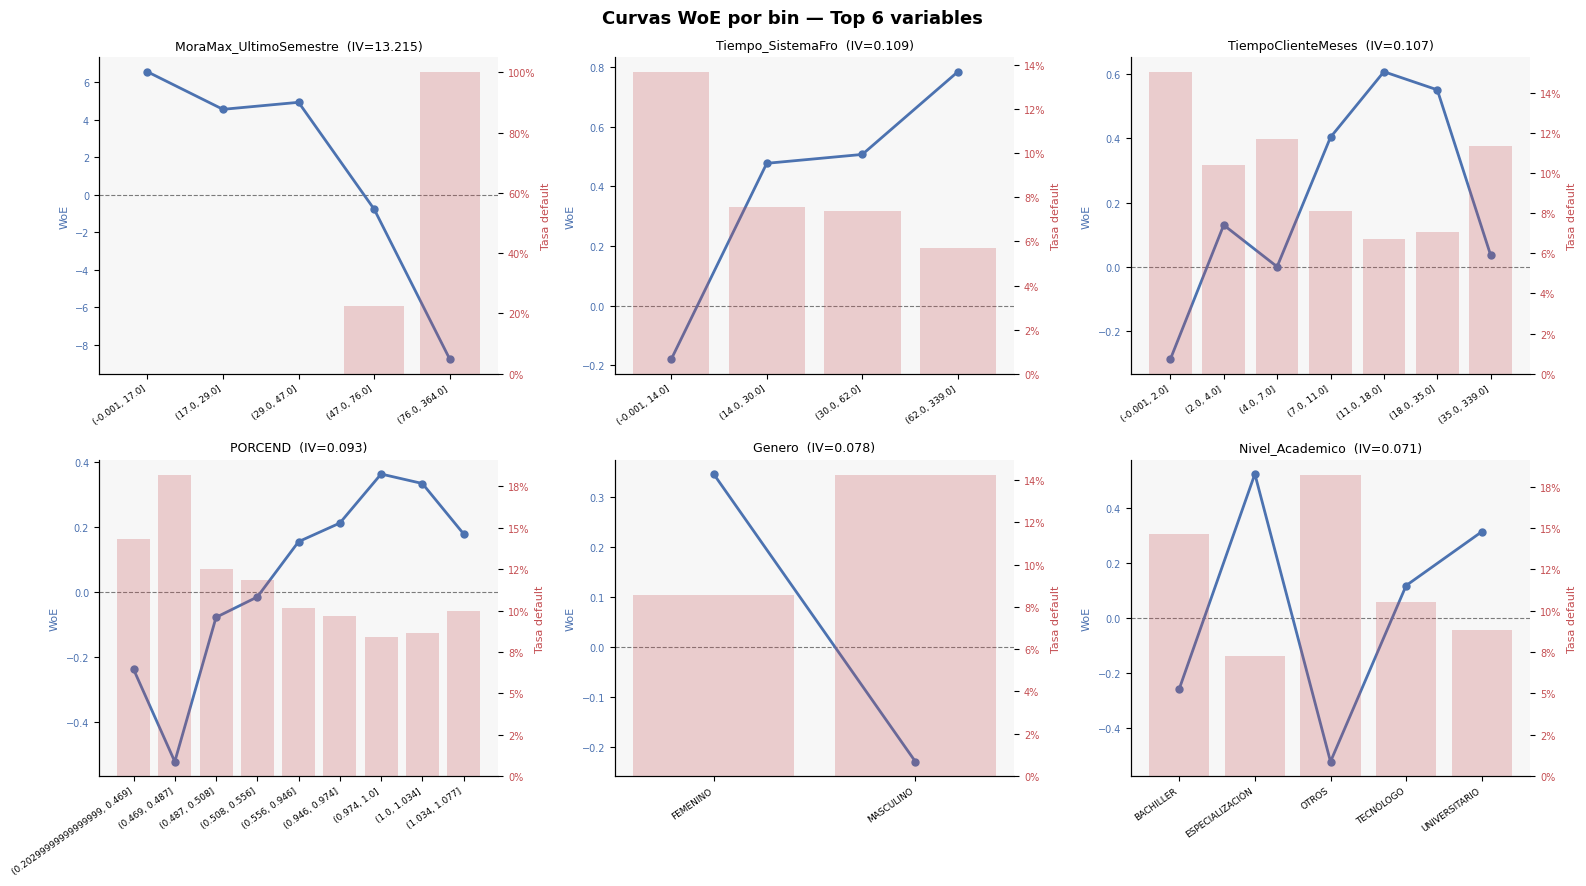

✓ Gráfico 6: curvas WoE top 6


In [31]:
# =============================================================================
# CURVAS WOE — top 6 variables
# =============================================================================
 
top6 = df_iv.head(6)["variable"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Curvas WoE por bin — Top 6 variables",
             fontsize=13, fontweight="bold")
axes = axes.flatten()
 
for i, col in enumerate(top6):
    ax   = axes[i]
    det  = resultados_iv[col]["detalle"].copy()
    det["tasa_default"] = det["n_malos"] / det["n"]
    x    = range(len(det))
    ax2  = ax.twinx()
 
    ax2.bar(x, det["tasa_default"], alpha=0.25, color=COLOR_MALO)
    ax2.set_ylabel("Tasa default", color=COLOR_MALO, fontsize=8)
    ax2.tick_params(axis="y", labelcolor=COLOR_MALO, labelsize=7)
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
 
    ax.plot(x, det["woe"], marker="o", color=COLOR_BUENO,
            linewidth=2, markersize=5, zorder=5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(det["bin"], rotation=35, ha="right", fontsize=6.5)
    ax.set_ylabel("WoE", color=COLOR_BUENO, fontsize=8)
    ax.tick_params(axis="y", labelcolor=COLOR_BUENO, labelsize=7)
    ax.set_title(f"{col}  (IV={resultados_iv[col]['IV']:.3f})", fontsize=9)
 
plt.tight_layout()
plt.savefig("07_woe_top6.png", dpi=150, bbox_inches="tight")
#plt.close()
plt.show()
print("✓ Gráfico 6: curvas WoE top 6")

Las curvas WoE ideales son **monótonas**: a mayor score de riesgo, el WoE debe decrecer consistentemente. ```Tiempo_SistemaFro``` y ```TiempoClienteMeses``` muestran curvas casi monótonas — los clientes con mayor antigüedad tienen WoE positivo (más buenos que malos), mientras los nuevos tienen WoE negativo. ```PORCEND``` también es razonablemente monótono: mayor endeudamiento implica mayor riesgo. Las variables con curvas irregulares (```Genero```, ```Estado_Civil```) sugieren que su poder predictivo es real pero no lineal, lo que refuerza la elección de un modelo basado en árboles.

In [32]:
# =============================================================================
# RESUMEN FINAL
# =============================================================================
 
candidatas = df_iv[df_iv["IV"] >= 0.02]
descartar  = df_iv[df_iv["IV"] <  0.02]
 
print("\n" + "="*68)
print(f"VARIABLES CANDIDATAS PARA EL MODELO (IV >= 0.02) — {len(candidatas)} variables")
print("="*68)
print(candidatas[["variable", "IV", "clasificacion"]].to_string(index=False))
 
print("\n" + "="*68)
print(f"VARIABLES A DESCARTAR (IV < 0.02) — {len(descartar)} variables")
print("="*68)
print(descartar[["variable", "IV", "clasificacion"]].to_string(index=False))
print("="*68)


VARIABLES CANDIDATAS PARA EL MODELO (IV >= 0.02) — 11 variables
              variable        IV clasificacion
MoraMax_UltimoSemestre 13.214552    Sospechoso
     Tiempo_SistemaFro  0.108545      Moderado
    TiempoClienteMeses  0.106882      Moderado
               PORCEND  0.093174         Débil
                Genero  0.078264         Débil
       Nivel_Academico  0.071205         Débil
          Estado_Civil  0.053564         Débil
              Ingresos  0.049783         Débil
      GastosFamiliares  0.038179         Débil
  TiempoActividadAnios  0.024839         Débil
                  Edad  0.020826         Débil

VARIABLES A DESCARTAR (IV < 0.02) — 9 variables
                    variable       IV        clasificacion
                 TIPCONTRATO 0.017707 Sin poder predictivo
                   OCUPACION 0.014923 Sin poder predictivo
               PersonasCargo 0.005474 Sin poder predictivo
     Obligaciones_SistemaFro 0.004179 Sin poder predictivo
               Tipo_Viviend